In [1]:
""" 
The XXZ Heisenberg Chain (Anisotropic)This variation introduces an asymmetry parameter (\(\Delta \)). 
The Z-direction interaction has a different strength than the \(X\) and \(Y\) directions. 
This is highly popular for VQE benchmarks because changing \(\Delta \) completely changes the quantum phase of the matter.
"""

<>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
/tmp/ipykernel_1031/205948996.py:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  The \(XXZ\) Heisenberg Chain (Anisotropic)This variation introduces an asymmetry parameter (\(\Delta \)).


' \nThe \\(XXZ\\) Heisenberg Chain (Anisotropic)This variation introduces an asymmetry parameter (\\(\\Delta \\)). \nThe \\(Z\\)-direction interaction has a different strength than the \\(X\\) and \\(Y\\) directions. \nThis is highly popular for VQE benchmarks because changing \\(\\Delta \\) completely changes the quantum phase of the matter.\n'

## Run without SpSA and Rotosolve

In [ ]:
# Hydrogen-chain VQE optimizer benchmark (run-only).
#
# Compares Polyak-style adaptive stepping (GD and QNG) against constant-LR
# GD / Adam / QNG. Each optimizer is run 5 times and aggregated downstream.
#
# Before running:
#   1) Prepare a GPU environment (lightning.gpu). Without GPUs the larger
#      configs (12-14 qubits, QNG metric tensors) will be far too slow.
#   2) Set SAVE_DIR below if you want results somewhere other than ./results
#   3) This script only produces data files. A separate script reads the
#      JSONs and plots them.
#
# System ladder (STO-3G, 2 spin-orbitals per H atom -> 2*n qubits):
#   H2  -> 4 qubits,  2 layers
#   H3+ -> 6 qubits,  3 layers    (odd chains built as closed-shell cations)
#   H4  -> 8 qubits,  4 layers
#   H5+ -> 10 qubits, 5 layers
#   H6  -> 12 qubits, 6 layers
#   H7+ -> 14 qubits, 7 layers

import os
import json

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import scipy.sparse.linalg as ssl

# ----------------------------- configuration -----------------------------
# (n_atoms, expected_num_qubits, num_layers)
CONFIGS = [
    # (2, 4, 2),
    (7, 14, 7),
]

N_STEPS = 200                 # optimization steps per run
N_REPEATS = 5                 # runs per optimizer (aggregated downstream)
PATIENCE = 5                  # no-improvement steps before switching to constant LR
BOND = 1.3228                 # nearest-neighbour H-H spacing in Bohr (~0.7 A)
CONST_LRS = [0.001, 0.01, 0.1, 0.5]
SAVE_DIR = "results"
DENSE_MAX_QUBITS = 10         # <= this: dense eigvalsh; above: sparse eigsh
SEED_BASE = 1234              # per-config seed = SEED_BASE + n_atoms; delete seeding for fresh RNG
# -------------------------------------------------------------------------


def build_hamiltonian(n_atoms):
    """Linear hydrogen chain along z. Odd chains -> closed-shell cation."""
    symbols = ["H"] * n_atoms
    coords = np.array(
        [[0.0, 0.0, (i - (n_atoms - 1) / 2.0) * BOND] for i in range(n_atoms)]
    ).flatten()
    charge = 0 if n_atoms % 2 == 0 else 1
    H, num_qubits = qml.qchem.molecular_hamiltonian(symbols, coords, charge=charge)
    return H, num_qubits, charge


def reference_spectrum(H, num_qubits):
    """Return (ground-state energy, spectral gap) of the full Hamiltonian."""
    if num_qubits <= DENSE_MAX_QUBITS:
        eig = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
    else:
        sm = H.sparse_matrix(wire_order=range(num_qubits))
        eig = std_np.sort(ssl.eigsh(sm, k=2, which="SA", return_eigenvectors=False))
    return float(eig[0]), float(eig[1] - eig[0])


def run_config(n_atoms, num_qubits_expected, num_layers):
    H, num_qubits, charge = build_hamiltonian(n_atoms)
    assert num_qubits == num_qubits_expected, (
        f"H{n_atoms} gave {num_qubits} qubits, expected {num_qubits_expected}"
    )

    print(f"\n=== H{n_atoms} (charge={charge}) | {num_qubits} qubits, {num_layers} layers ===")

    # Reproducible per config; remove these two lines for fresh randomness.
    np.random.seed(SEED_BASE + n_atoms)

    dev = qml.device("lightning.gpu", wires=num_qubits)

    def ansatz(params):
        for layer in range(num_layers):
            for q in range(num_qubits):
                qml.RX(params[layer, q, 0], wires=q)
                qml.RY(params[layer, q, 1], wires=q)
            for q in range(num_qubits - 1):
                qml.CNOT(wires=[q, q + 1])

    @qml.qnode(dev)
    def cost_fn(params):
        ansatz(params)
        return qml.expval(H)

    @qml.qnode(dev)
    def var_fn(params):
        ansatz(params)
        return qml.var(H)

    grad_fn = qml.grad(cost_fn)

    gse, gap = reference_spectrum(H, num_qubits)
    coeffs, _ = H.terms()
    h1_norm = float(np.sum(np.abs(np.array(coeffs))))
    print(f"    GSE = {gse:.6f}, gap = {gap:.6f}, 1-norm = {h1_norm:.4f}")

    sgd_lrs = adam_lrs = qng_lrs = CONST_LRS

    all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
    all_sgd = {lr: [] for lr in sgd_lrs}
    all_adam = {lr: [] for lr in adam_lrs}
    all_qng = {lr: [] for lr in qng_lrs}

    for rep in range(N_REPEATS):
        params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
        initial_params = params.copy()

        # -------------------- Polyak -> GD (our method) --------------------
        costs = []
        best_cost = np.inf
        best_params = params.copy()
        no_improve = 0
        refining = False
        lr_const = None
        switch = None

        for step in range(N_STEPS):
            cost = cost_fn(params)
            costs.append(cost)
            if step % 10 == 0:
                print(f"    [rep {rep+1}] step {step:03d}: cost = {cost:.6f}")

            if cost < best_cost:
                best_cost = cost
                best_params = params.copy()
                no_improve = 0
            else:
                no_improve += 1

            if not refining and no_improve >= PATIENCE:
                refining = True
                params = best_params.copy()
                lr_const = 0.1
                no_improve = 0
                switch = step + 1

            grad = grad_fn(params)

            if not refining:
                var = var_fn(params)
                std = np.sqrt(var)
                grad_norm_sq = np.sum(grad ** 2)
                lr = std / (grad_norm_sq + 1e-8)
            else:
                lr = lr_const

            params = params - lr * grad

        # ---------------------- constant-LR baselines ----------------------
        for lr in sgd_lrs:
            sgd_params = initial_params.copy()
            sgd_costs = []
            for step in range(N_STEPS):
                sgd_costs.append(cost_fn(sgd_params))
                sgd_grad = grad_fn(sgd_params)
                sgd_params = sgd_params - lr * sgd_grad
            all_sgd[lr].append([float(c) for c in sgd_costs])

        for lr in adam_lrs:
            adam_params = initial_params.copy()
            adam_costs = []
            adam_opt = qml.AdamOptimizer(stepsize=lr)
            for step in range(N_STEPS):
                adam_costs.append(cost_fn(adam_params))
                adam_params = adam_opt.step(cost_fn, adam_params)
            all_adam[lr].append([float(c) for c in adam_costs])

        for lr in qng_lrs:
            qng_params = initial_params.copy()
            qng_costs = []
            qng_opt = qml.QNGOptimizer(stepsize=lr)
            for step in range(N_STEPS):
                qng_costs.append(cost_fn(qng_params))
                qng_params = qng_opt.step(cost_fn, qng_params)
            all_qng[lr].append([float(c) for c in qng_costs])

        # -------------------- Polyak -> QNG (our method) -------------------
        qng_pc_params = initial_params.copy()
        qng_pc_costs = []
        best_cost_qng = np.inf
        best_params_qng = qng_pc_params.copy()
        no_improve_qng = 0
        refining_qng = False
        switch_qng = None
        qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

        for step in range(N_STEPS):
            cost = cost_fn(qng_pc_params)
            qng_pc_costs.append(cost)

            if cost < best_cost_qng:
                best_cost_qng = cost
                best_params_qng = qng_pc_params.copy()
                no_improve_qng = 0
            else:
                no_improve_qng += 1

            if not refining_qng and no_improve_qng >= PATIENCE:
                refining_qng = True
                qng_pc_params = best_params_qng.copy()
                no_improve_qng = 0
                switch_qng = step + 1

            if not refining_qng:
                var = var_fn(qng_pc_params)
                qng_pc_opt.stepsize = 1 / (4 * var)
            else:
                qng_pc_opt.stepsize = 0.1

            qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

        # ---------------------------- collect ----------------------------
        all_costs.append([float(c) for c in costs])
        all_best.append(std_np.minimum.accumulate(all_costs[-1]))
        all_qng_pc.append([float(c) for c in qng_pc_costs])
        all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
        all_switch.append(switch)
        all_switch_qng.append(switch_qng)

    best_curve = std_np.mean(all_best, axis=0)
    print(f"    Average best cost = {best_curve[-1]:.6f}  (GSE = {gse:.6f})")

    # ------------------------------ serialize ------------------------------
    x = list(range(1, N_STEPS + 1))
    results = {
        "num_qubits": int(num_qubits),
        "num_layers": int(num_layers),
        "n_atoms": int(n_atoms),
        "charge": int(charge),
        "gse": gse,
        "spectral_gap": gap,
        "h1_norm": h1_norm,
        "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {},
    }

    for name, lrs, data in [("sgd", sgd_lrs, all_sgd),
                            ("adam", adam_lrs, all_adam),
                            ("qng", qng_lrs, all_qng)]:
        for lr in lrs:
            d = {}
            for r in range(N_REPEATS):
                i = r + 1
                d[f"x{i}"] = x
                d[f"loss{i}"] = [float(c) for c in data[lr][r]]
            results[name][f"lr_{lr}"] = d

    for r in range(N_REPEATS):
        i = r + 1
        results["polyak_gd"][f"x{i}"] = x
        results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
        results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
        results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
        results["polyak_qng"][f"x{i}"] = x
        results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
        results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
        results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

    os.makedirs(SAVE_DIR, exist_ok=True)
    save_path = os.path.join(SAVE_DIR, f"{num_qubits}q_{num_layers}l.json")
    with open(save_path, "w") as f:
        json.dump(results, f)
    print(f"    saved -> {save_path}")


if __name__ == "__main__":
    for n_atoms, num_qubits, num_layers in CONFIGS:
        run_config(n_atoms, num_qubits, num_layers)
    print("\nAll configs complete.")


=== H7 (charge=1) | 14 qubits, 7 layers ===
    GSE = -3.490054, gap = 0.000000, 1-norm = 33.8758
    [rep 1] step 000: cost = 2.474622
    [rep 1] step 010: cost = 2.046789
    [rep 1] step 020: cost = 0.852001
    [rep 1] step 030: cost = 0.120458
    [rep 1] step 040: cost = -1.349272
    [rep 1] step 050: cost = -1.788495
    [rep 1] step 060: cost = -1.904815
    [rep 1] step 070: cost = -2.048407
    [rep 1] step 080: cost = -2.081920
    [rep 1] step 090: cost = -2.105990
    [rep 1] step 100: cost = -2.124529
    [rep 1] step 110: cost = -2.139558
    [rep 1] step 120: cost = -2.152246
    [rep 1] step 130: cost = -2.163230
    [rep 1] step 140: cost = -2.172842
    [rep 1] step 150: cost = -2.181259
    [rep 1] step 160: cost = -2.188586
    [rep 1] step 170: cost = -2.194911
    [rep 1] step 180: cost = -2.200322
    [rep 1] step 190: cost = -2.204915
    [rep 2] step 000: cost = 2.481356
    [rep 2] step 010: cost = 2.314561
    [rep 2] step 020: cost = 2.190990
    [rep 2]

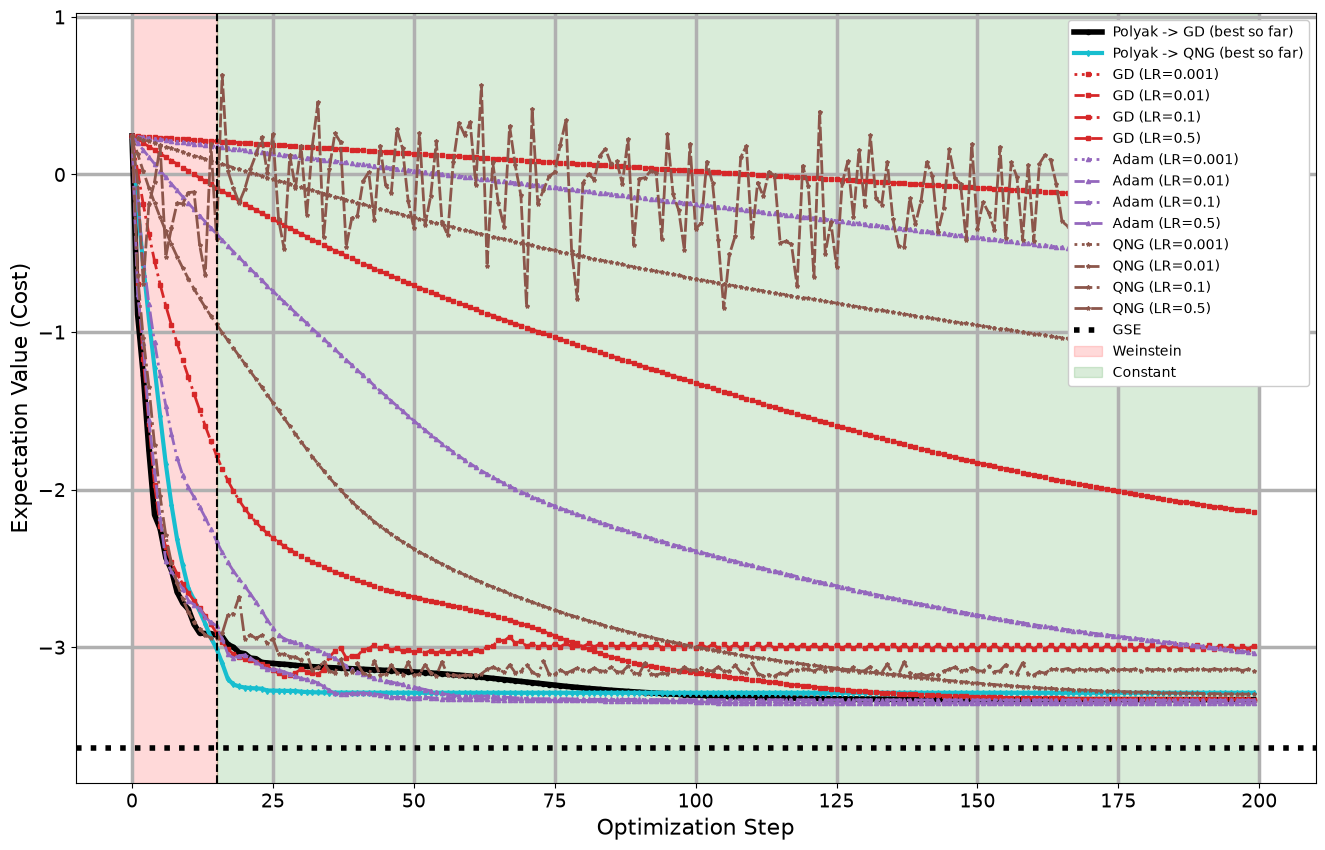

In [3]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

## Runs with SPSA and Rotosolve

In [ ]:
# Hydrogen-chain VQE optimizer benchmark (run-only).
#
# Compares Polyak-style adaptive stepping (GD and QNG) against constant-LR
# GD / Adam / QNG / SPSA, plus gradient-free Rotosolve. Each optimizer is run
# 5 times and aggregated downstream.
#
# Before running:
#   1) Prepare a GPU environment (lightning.gpu). Without GPUs the larger
#      configs (12-14 qubits, QNG metric tensors, Rotosolve sweeps) will be
#      far too slow.
#   2) Set SAVE_DIR below if you want results somewhere other than ./results
#   3) This script only produces data files. A separate script reads the
#      JSONs and plots them.
#
# System ladder (STO-3G, 2 spin-orbitals per H atom -> 2*n qubits):
#   H2  -> 4 qubits,  2 layers
#   H3+ -> 6 qubits,  3 layers    (odd chains built as closed-shell cations)
#   H4  -> 8 qubits,  4 layers
#   H5+ -> 10 qubits, 5 layers
#   H6  -> 12 qubits, 6 layers
#   H7+ -> 14 qubits, 7 layers
#
# ---------------------------------------------------------------------------
# WHAT CHANGED IN THIS REVISION
#
#   * The full 6-config ladder (4 -> 14 qubits) is enabled again.
#   * Two new optimizers: SPSA (stepsize scale `a` swept over the same four
#     values as the other constant-LR baselines) and Rotosolve (gradient-free,
#     closed-form per-parameter line search, 200 sweeps).
#   * RUN_OPTIMIZERS lets you choose which optimizers actually execute. It
#     defaults to SPSA + Rotosolve only, because the other five are already
#     done. Their code is untouched below - flip a flag to re-enable.
#   * Results MERGE into the existing results/{q}q_{l}l.json instead of
#     overwriting it. A one-time .bak copy is made before the first write.
#   * SKIP_EXISTING makes the script resumable: any (optimizer, lr, repeat)
#     whose curve is already in the JSON is skipped. Safe to kill and restart.
#   * The N_REPEATS initial parameter sets are now drawn UP FRONT, immediately
#     after seeding. This reproduces the exact same initial points as the
#     original rep-by-rep draw (nothing else consumed the RNG between reps),
#     so the new SPSA/Rotosolve curves start from the same points as your
#     completed GD/Adam/QNG runs. It also makes the results independent of
#     SPSA's own RNG consumption, which would otherwise shift later repeats.
# ---------------------------------------------------------------------------
import os
import json
import shutil
import time
from inspect import signature

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import scipy.sparse.linalg as ssl

# ----------------------------- configuration -----------------------------
# (n_atoms, expected_num_qubits, num_layers)
CONFIGS = [
    (2, 4, 2),
    (3, 6, 3),
    (4, 8, 4),
    (5, 10, 5),
    (6, 12, 6),
    (7, 14, 7),
]

# Which optimizers to run in this pass. Anything set to False is skipped
# entirely and whatever is already in the JSON for it is left alone.
RUN_OPTIMIZERS = {
    "polyak_gd":  False,   # already completed
    "polyak_qng": False,   # already completed
    "sgd":        False,   # already completed
    "adam":       False,   # already completed
    "qng":        False,   # already completed
    "spsa":       True,    # NEW
    "rotosolve":  True,    # NEW
}

N_STEPS = 200                 # optimization steps per run
ROTO_STEPS = 200              # Rotosolve sweeps per run (1 sweep ~ 2 evals/param)
N_REPEATS = 5                 # runs per optimizer (aggregated downstream)
PATIENCE = 5                  # no-improvement steps before switching to constant LR
BOND = 1.3228                 # nearest-neighbour H-H spacing in Bohr (~0.7 A)
CONST_LRS = [0.001, 0.01, 0.1, 0.5]
SAVE_DIR = "results"
DENSE_MAX_QUBITS = 10         # <= this: dense eigvalsh; above: sparse eigsh
SEED_BASE = 1234              # per-config seed = SEED_BASE + n_atoms; delete seeding for fresh RNG
DEVICE_NAME = "lightning.gpu"  # "lightning.qubit" / "default.qubit" for CPU testing

# SPSA hyperparameters. `a` is the step-size scale and is swept over the same
# four values as the other constant-LR baselines so the JSON layout matches.
# Effective step at iteration k is a / (A + k + 1)**alpha, with A = 0.1*maxiter.
SPSA_AS = CONST_LRS
SPSA_ALPHA = 0.602
SPSA_GAMMA = 0.101
SPSA_C = 0.2                  # perturbation magnitude

# Merge / resume behaviour
SKIP_EXISTING = True          # skip any (optimizer, lr, repeat) already in the JSON
BACKUP_EXISTING = True        # one-time .bak copy before the first write
REUSE_REFERENCE_SPECTRUM = True   # reuse gse/gap from the JSON instead of re-diagonalizing
ROTO_CHECKPOINT_EVERY = 10    # dump Rotosolve state every N sweeps so a kill can resume
# -------------------------------------------------------------------------

# Measured, not assumed: PennyLane 0.45 spends exactly 3 circuit evaluations per
# parameter per Rotosolve sweep (2 shifted points + the reference, no caching
# across substeps). At 14q/7L that is 196 params -> 588 evals/sweep ->
# 588,000 evals for 200 sweeps x 5 repeats. Lower ROTO_STEPS if that is too much;
# the curves stay valid, they just stop earlier.
ROTO_EVALS_PER_PARAM = 3

# Rotosolve's step() kwarg was renamed across PennyLane versions.
_ROTO_FREQ_KW = (
    "nums_frequency"
    if "nums_frequency" in signature(qml.RotosolveOptimizer.step).parameters
    else "num_freqs"
)


def build_hamiltonian(n_atoms):
    """Linear hydrogen chain along z. Odd chains -> closed-shell cation."""
    symbols = ["H"] * n_atoms
    coords = np.array(
        [[0.0, 0.0, (i - (n_atoms - 1) / 2.0) * BOND] for i in range(n_atoms)]
    ).flatten()
    charge = 0 if n_atoms % 2 == 0 else 1
    H, num_qubits = qml.qchem.molecular_hamiltonian(symbols, coords, charge=charge)
    return H, num_qubits, charge


def reference_spectrum(H, num_qubits):
    """Return (ground-state energy, spectral gap) of the full Hamiltonian."""
    if num_qubits <= DENSE_MAX_QUBITS:
        eig = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
    else:
        sm = H.sparse_matrix(wire_order=range(num_qubits))
        eig = std_np.sort(ssl.eigsh(sm, k=2, which="SA", return_eigenvectors=False))
    return float(eig[0]), float(eig[1] - eig[0])


# ------------------------------ json helpers ------------------------------
def load_existing(path):
    """Return the previously saved results dict, or {} if there is none."""
    if not os.path.exists(path):
        return {}
    try:
        with open(path) as f:
            return json.load(f)
    except (json.JSONDecodeError, OSError) as err:
        raise RuntimeError(
            f"{path} exists but could not be parsed ({err}). Move it aside before rerunning."
        )


def save_results(results, path):
    """Write via a temp file + rename so a crash can never truncate good data."""
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        json.dump(results, f)
    os.replace(tmp, path)


def backup_once(path):
    bak = path + ".bak"
    if os.path.exists(path) and not os.path.exists(bak):
        shutil.copyfile(path, bak)
        print(f"    backup -> {bak}")


def have_flat(results, name, rep):
    """True if a flat (no-LR) optimizer already has this repeat stored."""
    return f"loss{rep + 1}" in results.get(name, {})


def have_lr(results, name, lr, rep):
    """True if an LR-swept optimizer already has this (lr, repeat) stored."""
    return f"loss{rep + 1}" in results.get(name, {}).get(f"lr_{lr}", {})


# --------------------------- rotosolve checkpoints ---------------------------
# A single Rotosolve repeat at 14 qubits is hours of work, so its state is
# dumped periodically. Rotosolve is deterministic given the current parameters,
# so restoring them resumes the identical trajectory.
def ckpt_path(num_qubits, num_layers, rep):
    return os.path.join(SAVE_DIR, f".ckpt_{num_qubits}q_{num_layers}l_rotosolve_rep{rep + 1}.json")


def load_ckpt(path, shape):
    if not os.path.exists(path):
        return None
    try:
        with open(path) as f:
            ck = json.load(f)
    except (json.JSONDecodeError, OSError):
        return None
    if tuple(ck.get("shape", ())) != tuple(shape) or ck.get("roto_steps") != ROTO_STEPS:
        return None      # config changed underneath the checkpoint; start over
    if ck["sweep"] != len(ck["costs"]) or ck["sweep"] >= ROTO_STEPS:
        return None
    return ck


def save_ckpt(path, sweep, params, costs, evals):
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        json.dump({
            "sweep": sweep,
            "roto_steps": ROTO_STEPS,
            "shape": list(std_np.shape(params)),
            "params": std_np.asarray(params, dtype=float).tolist(),
            "costs": costs,
            "evals": evals,
        }, f)
    os.replace(tmp, path)


# -------------------------------- main run --------------------------------
def run_config(n_atoms, num_qubits_expected, num_layers):
    H, num_qubits, charge = build_hamiltonian(n_atoms)
    assert num_qubits == num_qubits_expected, (
        f"H{n_atoms} gave {num_qubits} qubits, expected {num_qubits_expected}"
    )
    print(f"\n=== H{n_atoms} (charge={charge}) | {num_qubits} qubits, {num_layers} layers ===")

    os.makedirs(SAVE_DIR, exist_ok=True)
    save_path = os.path.join(SAVE_DIR, f"{num_qubits}q_{num_layers}l.json")
    results = load_existing(save_path)
    if results:
        print(f"    merging into existing {save_path}")
        if BACKUP_EXISTING:
            backup_once(save_path)

    # Reproducible per config; remove these two lines for fresh randomness.
    # Drawing all repeats up front reproduces the original per-rep draw exactly
    # (nothing else touched the RNG between reps) and keeps the initial points
    # independent of whatever RNG the optimizers themselves consume.
    np.random.seed(SEED_BASE + n_atoms)
    init_params = [
        np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
        for _ in range(N_REPEATS)
    ]

    dev = qml.device(DEVICE_NAME, wires=num_qubits)

    def ansatz(params):
        for layer in range(num_layers):
            for q in range(num_qubits):
                qml.RX(params[layer, q, 0], wires=q)
                qml.RY(params[layer, q, 1], wires=q)
            for q in range(num_qubits - 1):
                qml.CNOT(wires=[q, q + 1])

    @qml.qnode(dev)
    def cost_fn(params):
        ansatz(params)
        return qml.expval(H)

    @qml.qnode(dev)
    def var_fn(params):
        ansatz(params)
        return qml.var(H)

    grad_fn = qml.grad(cost_fn)

    # Rotosolve wrapper: identical to cost_fn but counts circuit evaluations so
    # the curve can be replotted against cost rather than sweep index. The
    # argument MUST stay named `params` - Rotosolve keys nums_frequency by the
    # objective's argument name.
    eval_counter = [0]

    def roto_cost(params):
        eval_counter[0] += 1
        return cost_fn(params)

    roto_nums_freq = {
        "params": {idx: 1 for idx in std_np.ndindex(num_layers, num_qubits, 2)}
    }
    n_params = num_layers * num_qubits * 2

    # ---------------------------- reference data ----------------------------
    if REUSE_REFERENCE_SPECTRUM and "gse" in results and "spectral_gap" in results:
        gse, gap = float(results["gse"]), float(results["spectral_gap"])
        print("    reusing GSE / gap from the existing json (no re-diagonalization)")
    else:
        gse, gap = reference_spectrum(H, num_qubits)
    coeffs, _ = H.terms()
    h1_norm = float(np.sum(np.abs(np.array(coeffs))))
    print(f"    GSE = {gse:.6f}, gap = {gap:.6f}, 1-norm = {h1_norm:.4f}")

    evals_per_sweep = ROTO_EVALS_PER_PARAM * n_params
    if RUN_OPTIMIZERS["rotosolve"]:
        est = ROTO_STEPS * (evals_per_sweep + 1) * N_REPEATS
        print(f"    Rotosolve: {n_params} params -> {evals_per_sweep} evals/sweep, "
              f"~{est:,} circuit evaluations for this config")

    sgd_lrs = adam_lrs = qng_lrs = CONST_LRS

    # ------------------------------ metadata ------------------------------
    results.update({
        "num_qubits": int(num_qubits),
        "num_layers": int(num_layers),
        "n_atoms": int(n_atoms),
        "charge": int(charge),
        "gse": gse,
        "spectral_gap": gap,
        "h1_norm": h1_norm,
    })
    for key in ("polyak_gd", "polyak_qng", "sgd", "adam", "qng", "spsa", "rotosolve"):
        results.setdefault(key, {})
    results.setdefault("meta", {})
    results["meta"].update({
        "n_steps": N_STEPS,
        "roto_steps": ROTO_STEPS,
        "n_repeats": N_REPEATS,
        "patience": PATIENCE,
        "bond": BOND,
        "const_lrs": CONST_LRS,
        "seed_base": SEED_BASE,
        "spsa": {"a_values": SPSA_AS, "alpha": SPSA_ALPHA,
                 "gamma": SPSA_GAMMA, "c": SPSA_C, "A": 0.1 * N_STEPS},
        "rotosolve": {"nums_frequency": 1, "n_params": n_params,
                      "evals_per_sweep": evals_per_sweep},
    })

    x = list(range(1, N_STEPS + 1))
    x_roto = list(range(1, ROTO_STEPS + 1))

    for rep in range(N_REPEATS):
        i = rep + 1
        initial_params = init_params[rep]
        t_rep = time.perf_counter()

        # -------------------- Polyak -> GD (our method) --------------------
        if RUN_OPTIMIZERS["polyak_gd"] and not (SKIP_EXISTING and have_flat(results, "polyak_gd", rep)):
            params = initial_params.copy()
            costs = []
            best_cost = np.inf
            best_params = params.copy()
            no_improve = 0
            refining = False
            lr_const = None
            switch = None

            for step in range(N_STEPS):
                cost = cost_fn(params)
                costs.append(cost)
                if step % 10 == 0:
                    print(f"    [rep {i}] step {step:03d}: cost = {cost:.6f}")

                if cost < best_cost:
                    best_cost = cost
                    best_params = params.copy()
                    no_improve = 0
                else:
                    no_improve += 1

                if not refining and no_improve >= PATIENCE:
                    refining = True
                    params = best_params.copy()
                    lr_const = 0.1
                    no_improve = 0
                    switch = step + 1

                grad = grad_fn(params)
                if not refining:
                    var = var_fn(params)
                    std = np.sqrt(var)
                    grad_norm_sq = np.sum(grad ** 2)
                    lr = std / (grad_norm_sq + 1e-8)
                else:
                    lr = lr_const
                params = params - lr * grad

            costs = [float(c) for c in costs]
            results["polyak_gd"][f"x{i}"] = x
            results["polyak_gd"][f"loss{i}"] = costs
            results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in std_np.minimum.accumulate(costs)]
            results["polyak_gd"][f"weinstein_vs_constant{i}"] = switch
            save_results(results, save_path)

        # ---------------------- constant-LR baselines ----------------------
        if RUN_OPTIMIZERS["sgd"]:
            for lr in sgd_lrs:
                if SKIP_EXISTING and have_lr(results, "sgd", lr, rep):
                    continue
                sgd_params = initial_params.copy()
                sgd_costs = []
                for step in range(N_STEPS):
                    sgd_costs.append(cost_fn(sgd_params))
                    sgd_grad = grad_fn(sgd_params)
                    sgd_params = sgd_params - lr * sgd_grad
                d = results["sgd"].setdefault(f"lr_{lr}", {})
                d[f"x{i}"] = x
                d[f"loss{i}"] = [float(c) for c in sgd_costs]
                save_results(results, save_path)

        if RUN_OPTIMIZERS["adam"]:
            for lr in adam_lrs:
                if SKIP_EXISTING and have_lr(results, "adam", lr, rep):
                    continue
                adam_params = initial_params.copy()
                adam_costs = []
                adam_opt = qml.AdamOptimizer(stepsize=lr)
                for step in range(N_STEPS):
                    adam_costs.append(cost_fn(adam_params))
                    adam_params = adam_opt.step(cost_fn, adam_params)
                d = results["adam"].setdefault(f"lr_{lr}", {})
                d[f"x{i}"] = x
                d[f"loss{i}"] = [float(c) for c in adam_costs]
                save_results(results, save_path)

        if RUN_OPTIMIZERS["qng"]:
            for lr in qng_lrs:
                if SKIP_EXISTING and have_lr(results, "qng", lr, rep):
                    continue
                qng_params = initial_params.copy()
                qng_costs = []
                qng_opt = qml.QNGOptimizer(stepsize=lr)
                for step in range(N_STEPS):
                    qng_costs.append(cost_fn(qng_params))
                    qng_params = qng_opt.step(cost_fn, qng_params)
                d = results["qng"].setdefault(f"lr_{lr}", {})
                d[f"x{i}"] = x
                d[f"loss{i}"] = [float(c) for c in qng_costs]
                save_results(results, save_path)

        # ------------------------------ SPSA ------------------------------
        # Two circuit evaluations per step regardless of parameter count. The
        # per-run seed keeps the Bernoulli perturbations reproducible and
        # independent of which other blocks ran in this pass.
        if RUN_OPTIMIZERS["spsa"]:
            for li, a in enumerate(SPSA_AS):
                if SKIP_EXISTING and have_lr(results, "spsa", a, rep):
                    continue
                t0 = time.perf_counter()
                np.random.seed(SEED_BASE + 1000 * n_atoms + 10 * rep + li)
                spsa_params = initial_params.copy()
                spsa_costs = []
                spsa_opt = qml.SPSAOptimizer(
                    maxiter=N_STEPS, alpha=SPSA_ALPHA, gamma=SPSA_GAMMA, c=SPSA_C, a=a
                )
                for step in range(N_STEPS):
                    spsa_costs.append(float(cost_fn(spsa_params)))
                    spsa_params = spsa_opt.step(cost_fn, spsa_params)
                d = results["spsa"].setdefault(f"lr_{a}", {})
                d[f"x{i}"] = x
                d[f"loss{i}"] = spsa_costs
                save_results(results, save_path)
                print(f"    [rep {i}] SPSA a={a}: final = {spsa_costs[-1]:.6f} "
                      f"({time.perf_counter() - t0:.1f}s)")

        # ---------------------------- Rotosolve ----------------------------
        # Gradient-free. Every sweep replaces each parameter with the exact
        # minimizer of the (sinusoidal, single-frequency) 1-D cross-section,
        # costing 2 evaluations per parameter. `evals{i}` records the running
        # circuit-evaluation count so the curve can be compared on cost.
        if RUN_OPTIMIZERS["rotosolve"] and not (SKIP_EXISTING and have_flat(results, "rotosolve", rep)):
            t0 = time.perf_counter()
            roto_opt = qml.RotosolveOptimizer()
            ckpt = ckpt_path(num_qubits, num_layers, rep)
            ck = load_ckpt(ckpt, initial_params.shape)

            if ck is not None:
                start = ck["sweep"]
                roto_costs, roto_evals = ck["costs"], ck["evals"]
                roto_params = np.tensor(std_np.array(ck["params"]), requires_grad=True)
                eval_counter[0] = roto_evals[-1] if roto_evals else 0
                print(f"    [rep {i}] resuming Rotosolve from checkpoint at sweep {start}")
            else:
                start = 0
                roto_params = initial_params.copy()
                roto_costs, roto_evals = [], []
                eval_counter[0] = 0

            for step in range(start, ROTO_STEPS):
                cost = float(roto_cost(roto_params))
                roto_costs.append(cost)
                roto_evals.append(int(eval_counter[0]))
                if step % 10 == 0:
                    print(f"    [rep {i}] rotosolve sweep {step:03d}: cost = {cost:.6f} "
                          f"({eval_counter[0]:,} evals, {time.perf_counter() - t0:.0f}s)", flush=True)
                roto_params = roto_opt.step(
                    roto_cost, roto_params, **{_ROTO_FREQ_KW: roto_nums_freq}
                )
                if isinstance(roto_params, (list, tuple)):
                    roto_params = roto_params[0]
                roto_params = np.tensor(roto_params, requires_grad=True)
                if ROTO_CHECKPOINT_EVERY and (step + 1) % ROTO_CHECKPOINT_EVERY == 0:
                    save_ckpt(ckpt, step + 1, roto_params, roto_costs, roto_evals)

            results["rotosolve"][f"x{i}"] = x_roto
            results["rotosolve"][f"loss{i}"] = roto_costs
            results["rotosolve"][f"best_loss{i}"] = [
                float(c) for c in std_np.minimum.accumulate(roto_costs)
            ]
            results["rotosolve"][f"evals{i}"] = roto_evals
            save_results(results, save_path)
            if os.path.exists(ckpt):
                os.remove(ckpt)
            print(f"    [rep {i}] Rotosolve: final = {roto_costs[-1]:.6f} "
                  f"({time.perf_counter() - t0:.1f}s, {roto_evals[-1]:,} evals)")

        # -------------------- Polyak -> QNG (our method) -------------------
        if RUN_OPTIMIZERS["polyak_qng"] and not (SKIP_EXISTING and have_flat(results, "polyak_qng", rep)):
            qng_pc_params = initial_params.copy()
            qng_pc_costs = []
            best_cost_qng = np.inf
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
            refining_qng = False
            switch_qng = None
            qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

            for step in range(N_STEPS):
                cost = cost_fn(qng_pc_params)
                qng_pc_costs.append(cost)

                if cost < best_cost_qng:
                    best_cost_qng = cost
                    best_params_qng = qng_pc_params.copy()
                    no_improve_qng = 0
                else:
                    no_improve_qng += 1

                if not refining_qng and no_improve_qng >= PATIENCE:
                    refining_qng = True
                    qng_pc_params = best_params_qng.copy()
                    no_improve_qng = 0
                    switch_qng = step + 1

                if not refining_qng:
                    var = var_fn(qng_pc_params)
                    qng_pc_opt.stepsize = 1 / (4 * var)
                else:
                    qng_pc_opt.stepsize = 0.1
                qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

            qng_pc_costs = [float(c) for c in qng_pc_costs]
            results["polyak_qng"][f"x{i}"] = x
            results["polyak_qng"][f"loss{i}"] = qng_pc_costs
            results["polyak_qng"][f"best_loss{i}"] = [
                float(c) for c in std_np.minimum.accumulate(qng_pc_costs)
            ]
            results["polyak_qng"][f"weinstein_vs_constant{i}"] = switch_qng
            save_results(results, save_path)

        print(f"    [rep {i}] done in {time.perf_counter() - t_rep:.1f}s")

    # ------------------------------ summary ------------------------------
    for name in ("polyak_gd", "polyak_qng", "rotosolve"):
        curves = [results[name][f"best_loss{r + 1}"] for r in range(N_REPEATS)
                  if f"best_loss{r + 1}" in results.get(name, {})]
        if curves:
            avg = std_np.mean([c[-1] for c in curves])
            print(f"    {name}: average best cost = {avg:.6f}  (GSE = {gse:.6f})")
    if results.get("spsa"):
        for a in SPSA_AS:
            d = results["spsa"].get(f"lr_{a}", {})
            finals = [d[f"loss{r + 1}"][-1] for r in range(N_REPEATS) if f"loss{r + 1}" in d]
            if finals:
                print(f"    spsa a={a}: average final cost = {std_np.mean(finals):.6f}")

    save_results(results, save_path)
    print(f"    saved -> {save_path}")


if __name__ == "__main__":
    t_start = time.perf_counter()
    print("running optimizers: " + ", ".join(k for k, v in RUN_OPTIMIZERS.items() if v))
    for n_atoms, num_qubits, num_layers in CONFIGS:
        run_config(n_atoms, num_qubits, num_layers)
    print(f"\nAll configs complete in {(time.perf_counter() - t_start) / 60:.1f} min.")

running optimizers: spsa, rotosolve

=== H2 (charge=0) | 4 qubits, 2 layers ===
    merging into existing results/4q_2l.json
    reusing GSE / gap from the existing json (no re-diagonalization)
    GSE = -1.136189, gap = 0.614306, 1-norm = 1.9901
    Rotosolve: 16 params -> 48 evals/sweep, ~49,000 circuit evaluations for this config
    [rep 1] done in 0.0s
    [rep 2] done in 0.0s
    [rep 3] done in 0.0s
    [rep 4] done in 0.0s
    [rep 5] done in 0.0s
    polyak_gd: average best cost = -1.004303  (GSE = -1.136189)
    polyak_qng: average best cost = -1.004610  (GSE = -1.136189)
    rotosolve: average best cost = -1.136189  (GSE = -1.136189)
    spsa a=0.001: average final cost = -0.088806
    spsa a=0.01: average final cost = -0.104979
    spsa a=0.1: average final cost = -0.268588
    spsa a=0.5: average final cost = -0.562302
    saved -> results/4q_2l.json

=== H3 (charge=1) | 6 qubits, 3 layers ===
    merging into existing results/6q_3l.json
    reusing GSE / gap from the exis

## Individual job written by Christopher

Step 000: Cost = -0.515511
Step 010: Cost = -5.313173
Step 020: Cost = -5.575991
Step 030: Cost = -5.747880
Step 040: Cost = -5.860560
Step 050: Cost = -5.954609
Step 060: Cost = -6.049032
Step 070: Cost = -6.160264
Step 080: Cost = -6.292688
Step 090: Cost = -6.422958
Step 100: Cost = -6.522800
Step 110: Cost = -6.597483
Step 120: Cost = -6.661914
Step 130: Cost = -6.721049
Step 140: Cost = -6.775130
Step 150: Cost = -6.825155
Step 160: Cost = -6.873698
Step 170: Cost = -6.923718
Step 180: Cost = -6.977914
Step 190: Cost = -7.039144
Step 000: Cost = -0.469495
Step 010: Cost = -5.624572
Step 020: Cost = -6.570972
Step 030: Cost = -7.278028
Step 040: Cost = -7.330775
Step 050: Cost = -7.351757
Step 060: Cost = -7.365874
Step 070: Cost = -7.378625
Step 080: Cost = -7.391304
Step 090: Cost = -7.404191
Step 100: Cost = -7.417273
Step 110: Cost = -7.430447
Step 120: Cost = -7.443604
Step 130: Cost = -7.456691
Step 140: Cost = -7.469728
Step 150: Cost = -7.482766
Step 160: Cost = -7.495796
S

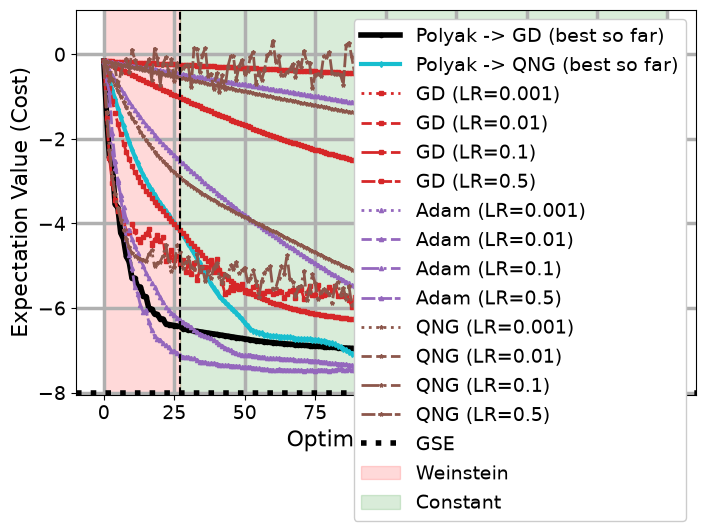

In [12]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 8
num_layers = 4
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

plt.figure(figsize=(8, 5))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

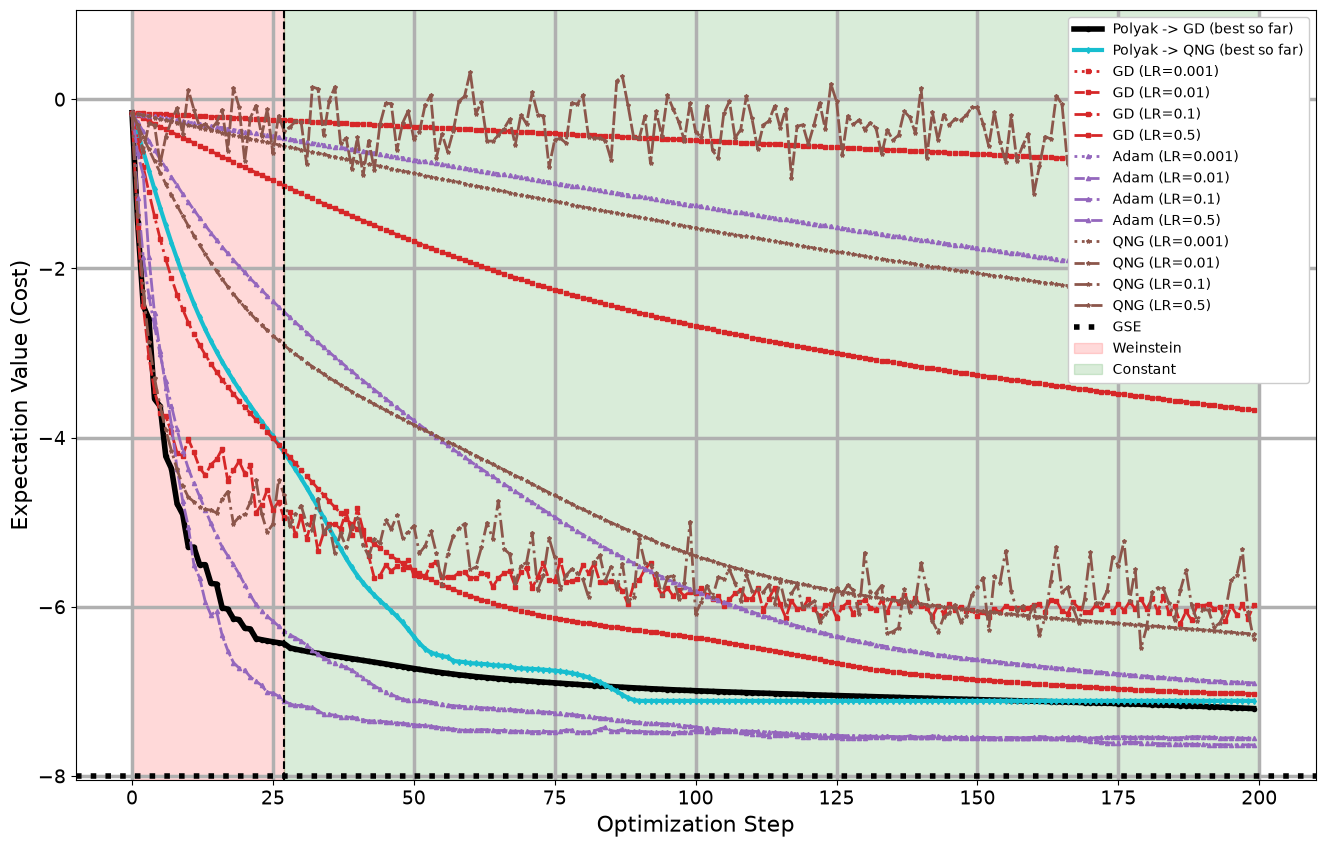

In [13]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

Step 000: Cost = 0.176848
Step 010: Cost = -7.317019
Step 020: Cost = -8.924388
Step 030: Cost = -9.000505
Step 040: Cost = -9.061358
Step 050: Cost = -9.093399
Step 060: Cost = -9.112077
Step 070: Cost = -9.124178
Step 080: Cost = -9.132970
Step 090: Cost = -9.140104
Step 100: Cost = -9.146466
Step 110: Cost = -9.152566
Step 120: Cost = -9.158731
Step 130: Cost = -9.165210
Step 140: Cost = -9.172243
Step 150: Cost = -9.180133
Step 160: Cost = -9.189317
Step 170: Cost = -9.200490
Step 180: Cost = -9.214834
Step 190: Cost = -9.234489
Step 000: Cost = -0.342901
Step 010: Cost = -5.278404
Step 020: Cost = -7.596335
Step 030: Cost = -8.118184
Step 040: Cost = -8.420848
Step 050: Cost = -8.451776
Step 060: Cost = -8.477609
Step 070: Cost = -8.501800
Step 080: Cost = -8.524177
Step 090: Cost = -8.544641
Step 100: Cost = -8.563409
Step 110: Cost = -8.580845
Step 120: Cost = -8.597309
Step 130: Cost = -8.613091
Step 140: Cost = -8.628422
Step 150: Cost = -8.643495
Step 160: Cost = -8.658503
St

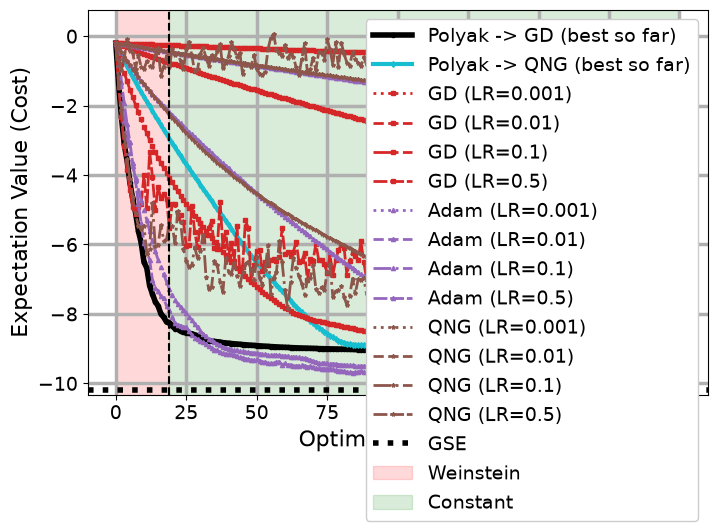

In [18]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 10
num_layers = 5
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

plt.figure(figsize=(8, 5))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

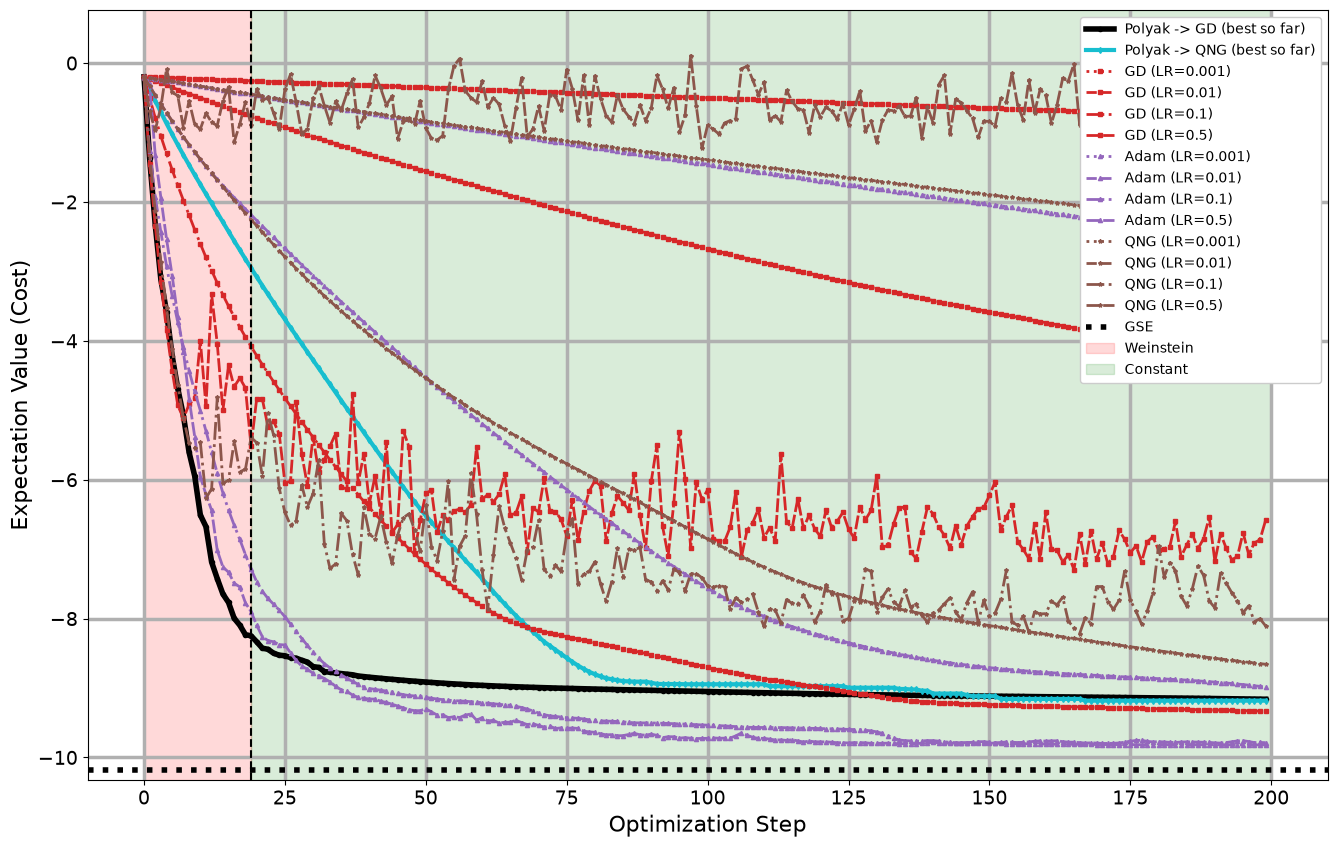

In [19]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [24]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 12
num_layers = 6
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

# plt.figure(figsize=(8, 5))
# plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
# plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
# styles = [':', '--', '-.', (0, (5, 1))]
# for j, lr in enumerate(sgd_lrs):
#     plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
# for j, lr in enumerate(adam_lrs):
#     plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
# for j, lr in enumerate(qng_lrs):
#     plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
# plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
# regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
# colors = {"Weinstein": "red", "Constant": "green"}
# labeled = set()
# start = 0
# for i in range(1, len(regimes) + 1):
#     if i == len(regimes) or regimes[i] != regimes[start]:
#         r = regimes[start]
#         plt.axvspan(start, i, color=colors[r], alpha=0.15,
#                     label=r if r not in labeled else None)
#         labeled.add(r)
#         if i < len(regimes):
#             plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
#         start = i
# plt.xlabel("Optimization Step", fontsize=16)
# plt.ylabel("Expectation Value (Cost)", fontsize=16)
# plt.tick_params(labelsize=14)
# plt.legend(fontsize=14, framealpha=1, loc='upper right')
# plt.grid(True, linewidth=2.5)
# plt.show()

Step 000: Cost = -0.220649
Step 010: Cost = -6.634606
Step 020: Cost = -9.980518
Step 030: Cost = -9.877298
Step 040: Cost = -10.812413
Step 050: Cost = -10.873923
Step 060: Cost = -10.934878
Step 070: Cost = -11.000684
Step 080: Cost = -11.076146
Step 090: Cost = -11.176834
Step 100: Cost = -11.339341
Step 110: Cost = -11.562331
Step 120: Cost = -11.721706
Step 130: Cost = -11.807065
Step 140: Cost = -11.872153
Step 150: Cost = -11.929053
Step 160: Cost = -11.973280
Step 170: Cost = -12.001177
Step 180: Cost = -12.015560
Step 190: Cost = -12.022165
Step 000: Cost = -0.182294
Step 010: Cost = -6.368008
Step 020: Cost = -10.026263
Step 030: Cost = -8.959989
Step 040: Cost = -11.879930
Step 050: Cost = -11.898196
Step 060: Cost = -11.910716
Step 070: Cost = -11.922579
Step 080: Cost = -11.934231
Step 090: Cost = -11.945616
Step 100: Cost = -11.956475
Step 110: Cost = -11.966466
Step 120: Cost = -11.975271
Step 130: Cost = -11.982699
Step 140: Cost = -11.988735
Step 150: Cost = -11.993518

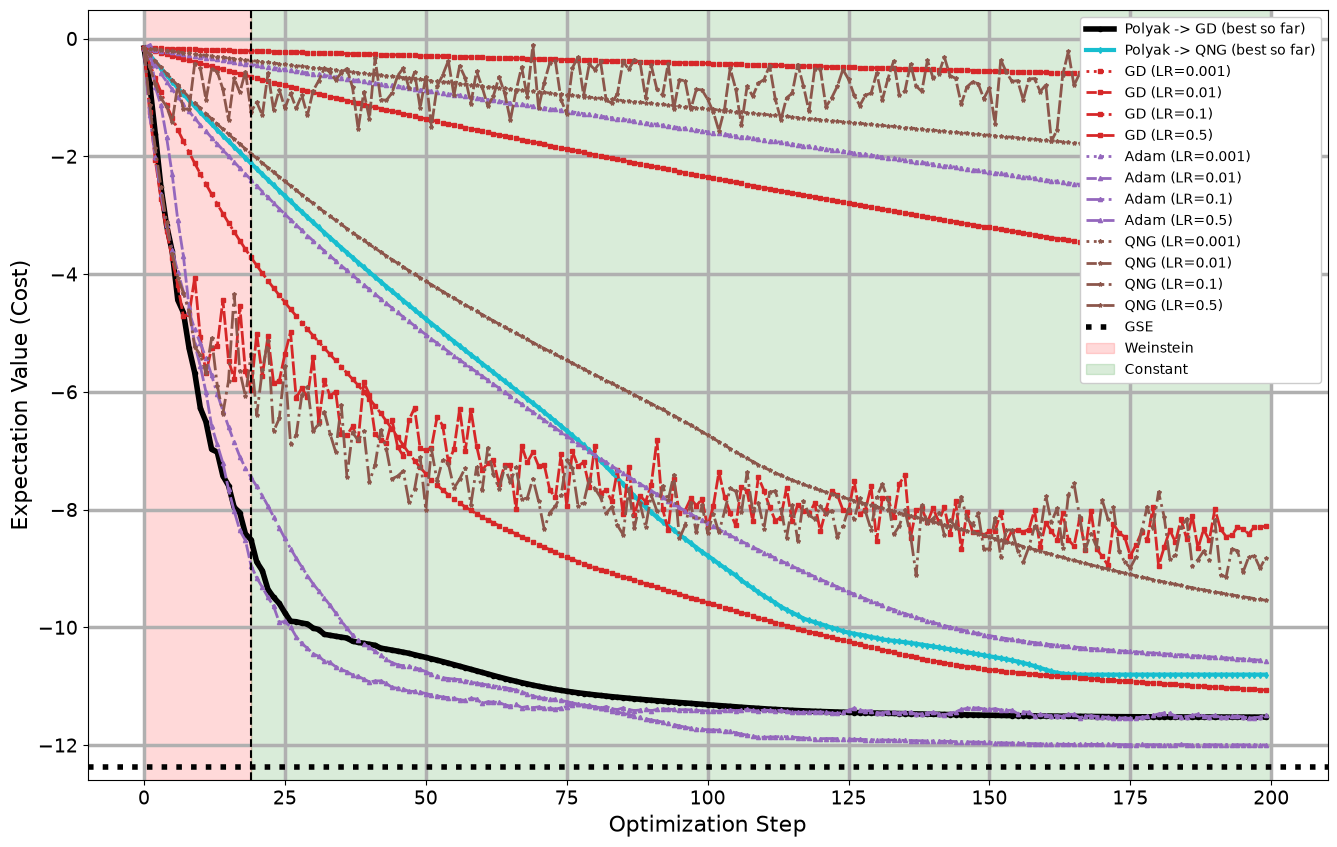

In [25]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [1]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 14
num_layers = 7
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

# plt.figure(figsize=(8, 5))
# plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
# plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
# styles = [':', '--', '-.', (0, (5, 1))]
# for j, lr in enumerate(sgd_lrs):
#     plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
# for j, lr in enumerate(adam_lrs):
#     plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
# for j, lr in enumerate(qng_lrs):
#     plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
# plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
# regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
# colors = {"Weinstein": "red", "Constant": "green"}
# labeled = set()
# start = 0
# for i in range(1, len(regimes) + 1):
#     if i == len(regimes) or regimes[i] != regimes[start]:
#         r = regimes[start]
#         plt.axvspan(start, i, color=colors[r], alpha=0.15,
#                     label=r if r not in labeled else None)
#         labeled.add(r)
#         if i < len(regimes):
#             plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
#         start = i
# plt.xlabel("Optimization Step", fontsize=16)
# plt.ylabel("Expectation Value (Cost)", fontsize=16)
# plt.tick_params(labelsize=14)
# plt.legend(fontsize=14, framealpha=1, loc='upper right')
# plt.grid(True, linewidth=2.5)
# plt.show()

Step 000: Cost = 0.160407
Step 010: Cost = -7.003727
Step 020: Cost = -10.122673
Step 030: Cost = -10.580446
Step 040: Cost = -11.165156
Step 050: Cost = -11.640002
Step 060: Cost = -11.857114
Step 070: Cost = -12.010171
Step 080: Cost = -12.133059
Step 090: Cost = -12.235146
Step 100: Cost = -12.325080
Step 110: Cost = -12.407642
Step 120: Cost = -12.482838
Step 130: Cost = -12.551315
Step 140: Cost = -12.617810
Step 150: Cost = -12.687935
Step 160: Cost = -12.765650
Step 170: Cost = -12.854366
Step 180: Cost = -12.955315
Step 190: Cost = -13.060635
Step 000: Cost = -0.118275
Step 010: Cost = -7.933119
Step 020: Cost = -10.930072
Step 030: Cost = -12.077560
Step 040: Cost = -13.111112
Step 050: Cost = -13.642554
Step 060: Cost = -13.660897
Step 070: Cost = -13.674195
Step 080: Cost = -13.684356
Step 090: Cost = -13.692470
Step 100: Cost = -13.699225
Step 110: Cost = -13.705055
Step 120: Cost = -13.710231
Step 130: Cost = -13.714928
Step 140: Cost = -13.719257
Step 150: Cost = -13.7232

plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [3]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 16
num_layers = 8
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

# plt.figure(figsize=(8, 5))
# plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
# plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
# styles = [':', '--', '-.', (0, (5, 1))]
# for j, lr in enumerate(sgd_lrs):
#     plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
# for j, lr in enumerate(adam_lrs):
#     plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
# for j, lr in enumerate(qng_lrs):
#     plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
# plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
# regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
# colors = {"Weinstein": "red", "Constant": "green"}
# labeled = set()
# start = 0
# for i in range(1, len(regimes) + 1):
#     if i == len(regimes) or regimes[i] != regimes[start]:
#         r = regimes[start]
#         plt.axvspan(start, i, color=colors[r], alpha=0.15,
#                     label=r if r not in labeled else None)
#         labeled.add(r)
#         if i < len(regimes):
#             plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
#         start = i
# plt.xlabel("Optimization Step", fontsize=16)
# plt.ylabel("Expectation Value (Cost)", fontsize=16)
# plt.tick_params(labelsize=14)
# plt.legend(fontsize=14, framealpha=1, loc='upper right')
# plt.grid(True, linewidth=2.5)
# plt.show()

MemoryError: Unable to allocate 64.0 GiB for an array with shape (65536, 65536) and data type complex128

In [ ]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [ ]:
### Plotting routine: 

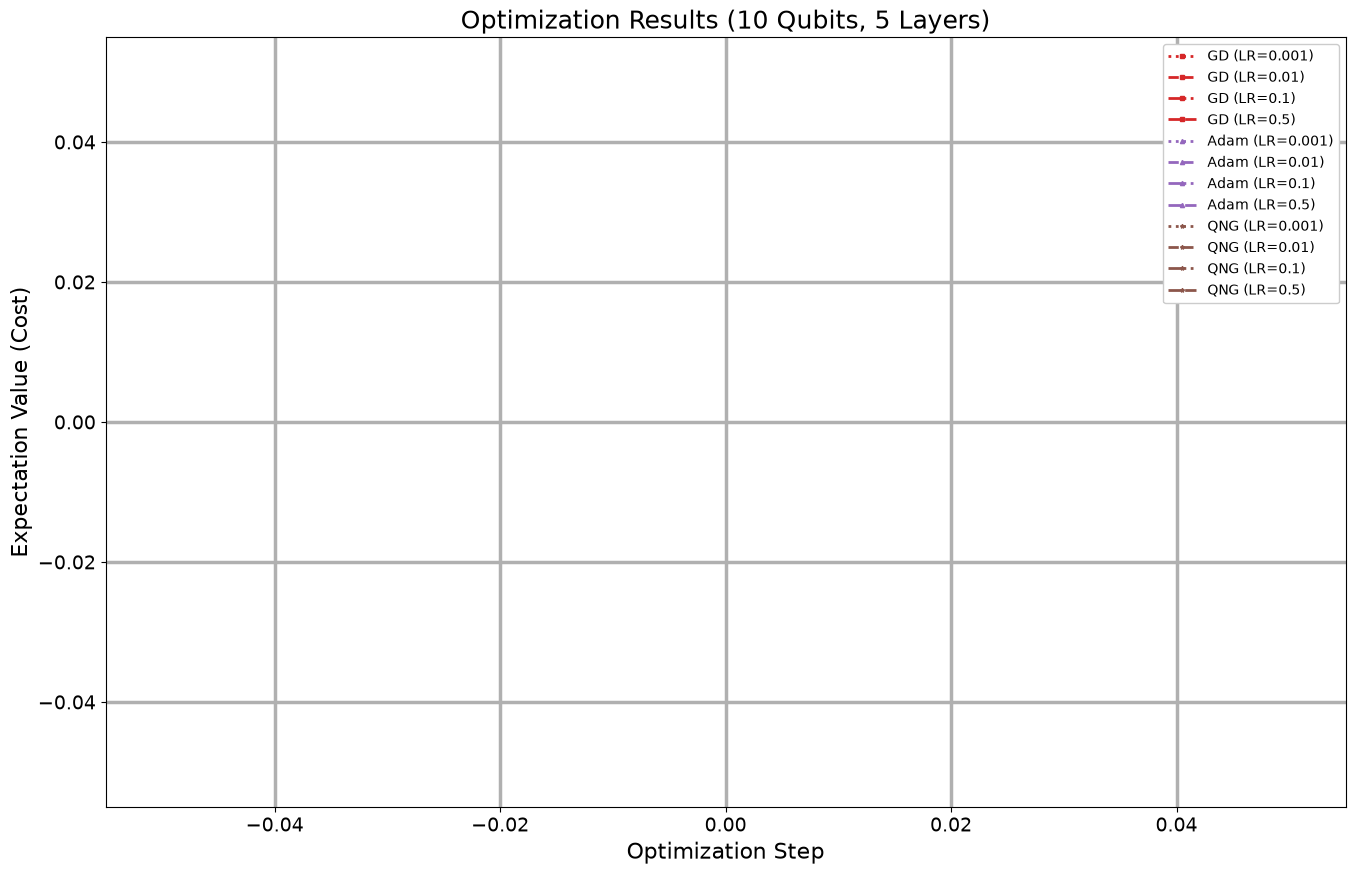

Saved plot: results/10q_5l.png


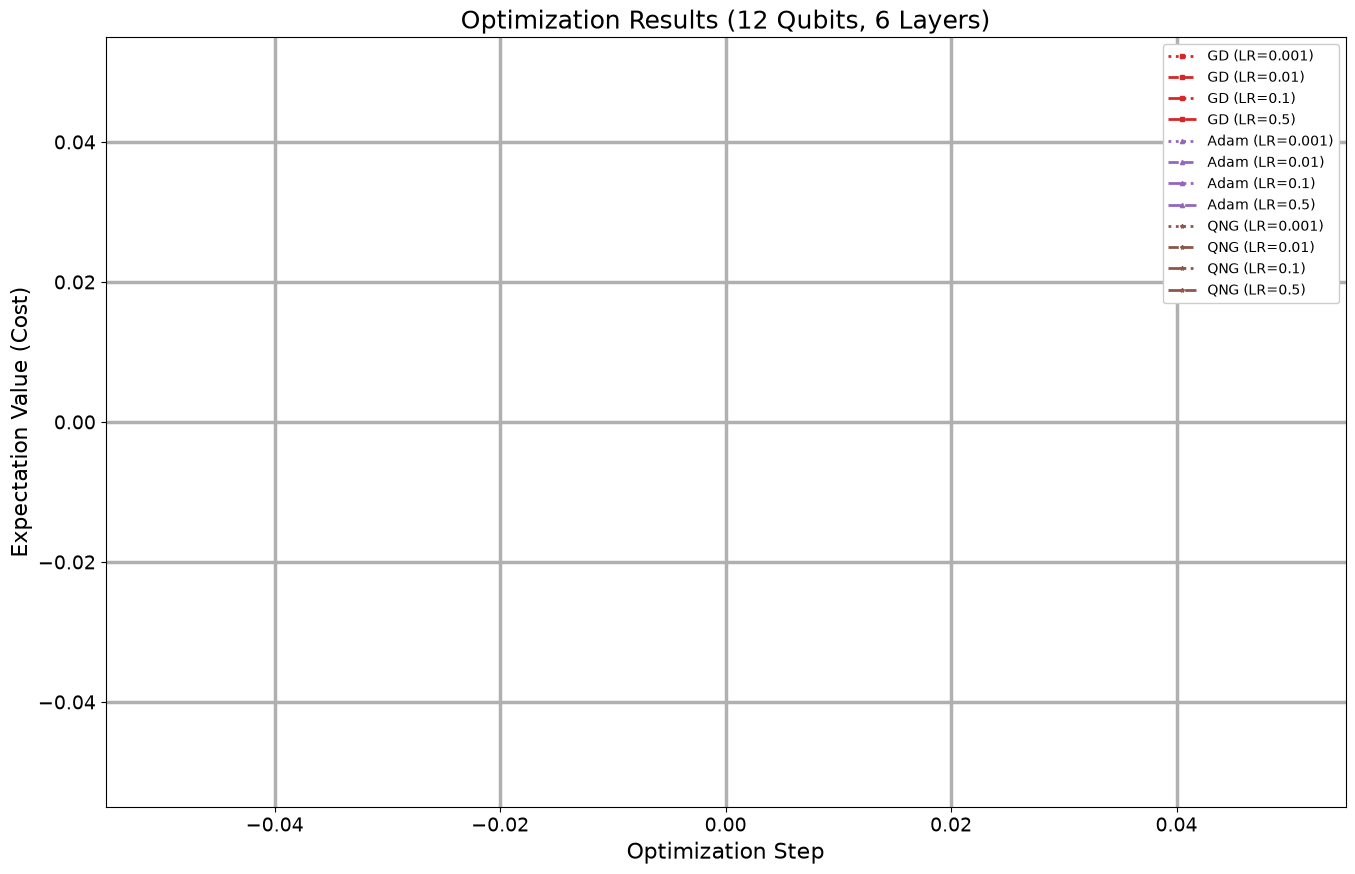

Saved plot: results/12q_6l.png


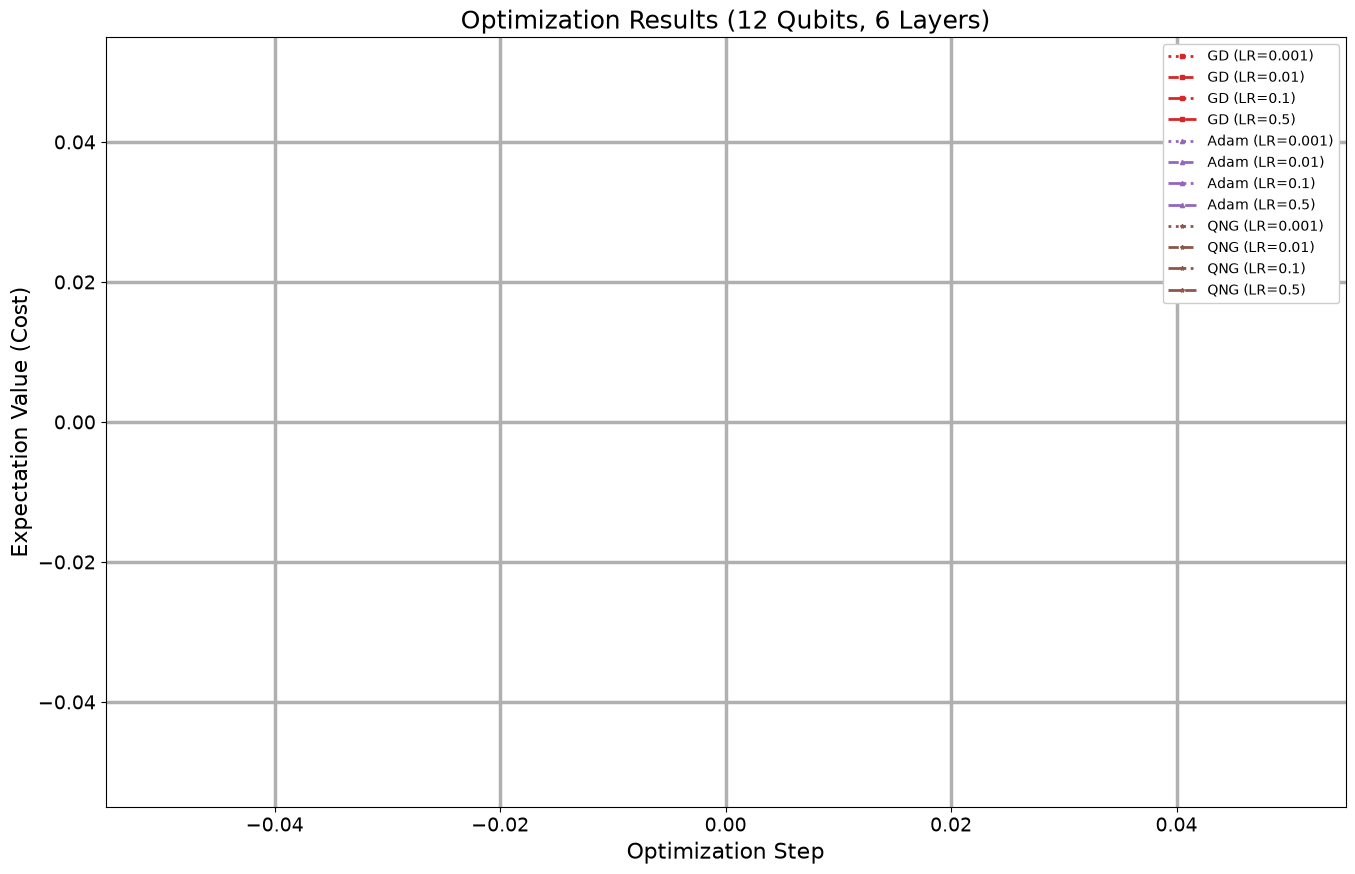

Saved plot: results/12q_6l_stopped.png


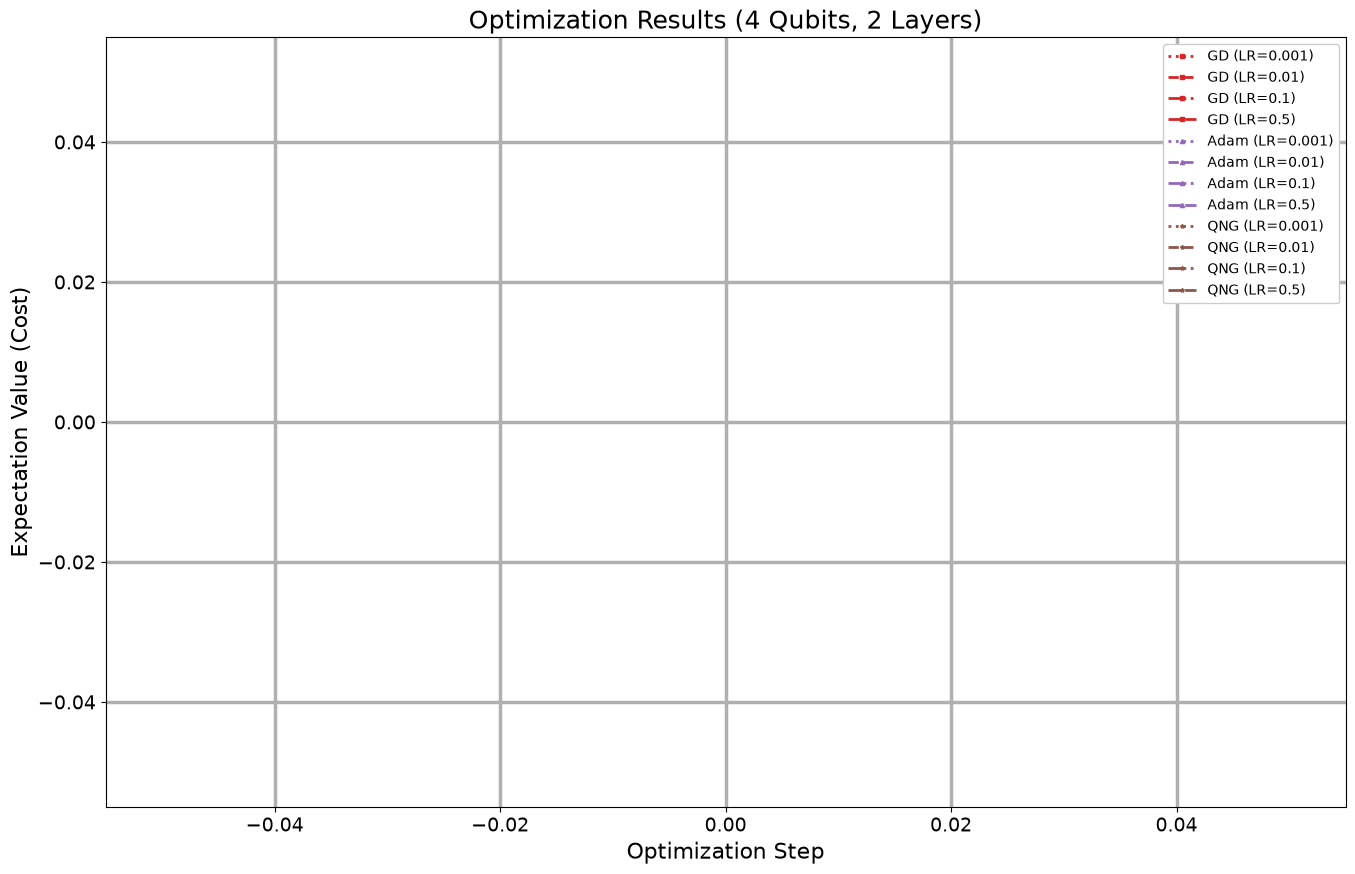

Saved plot: results/4q_2l.png


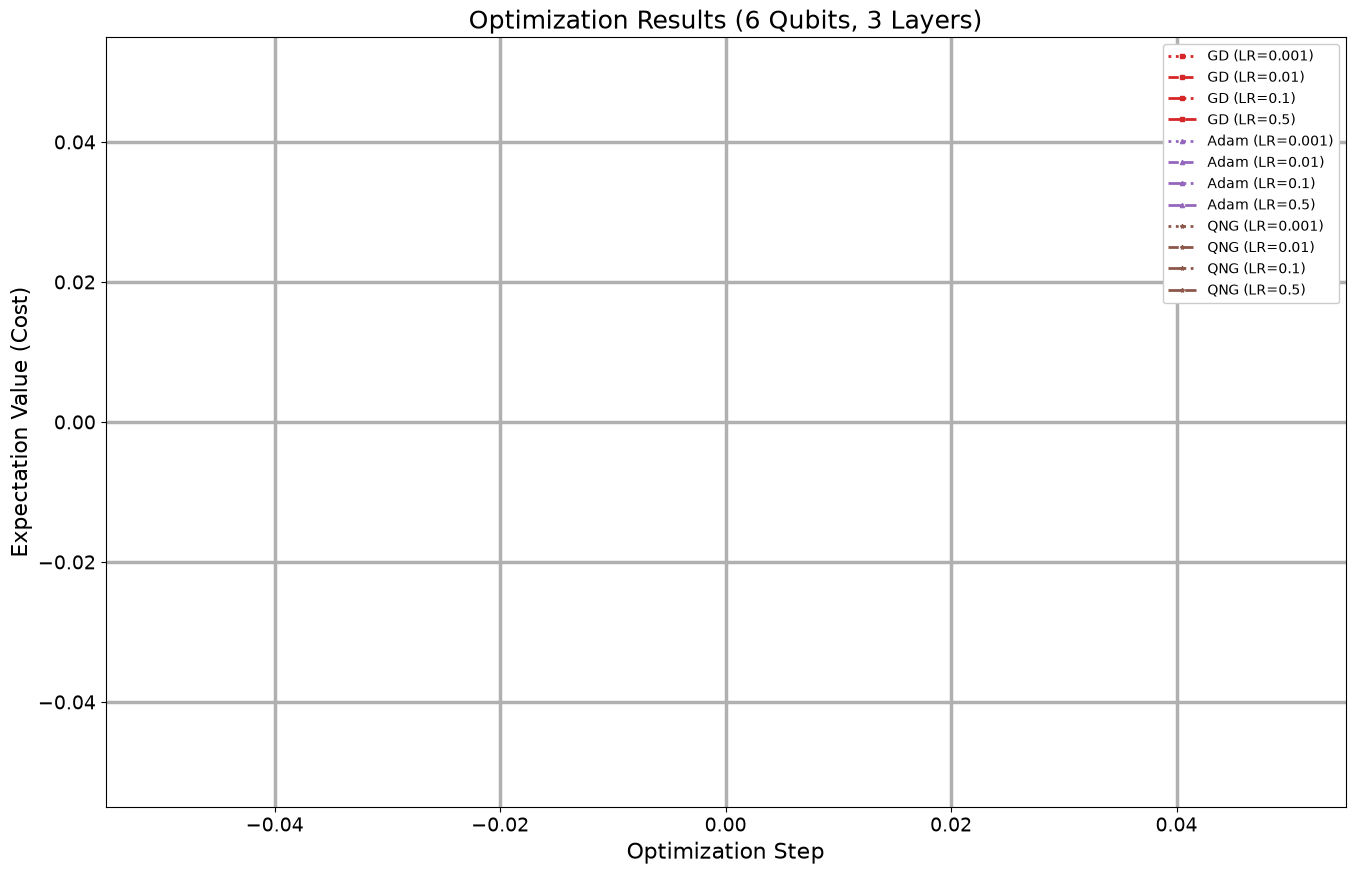

Saved plot: results/6q_3l.png


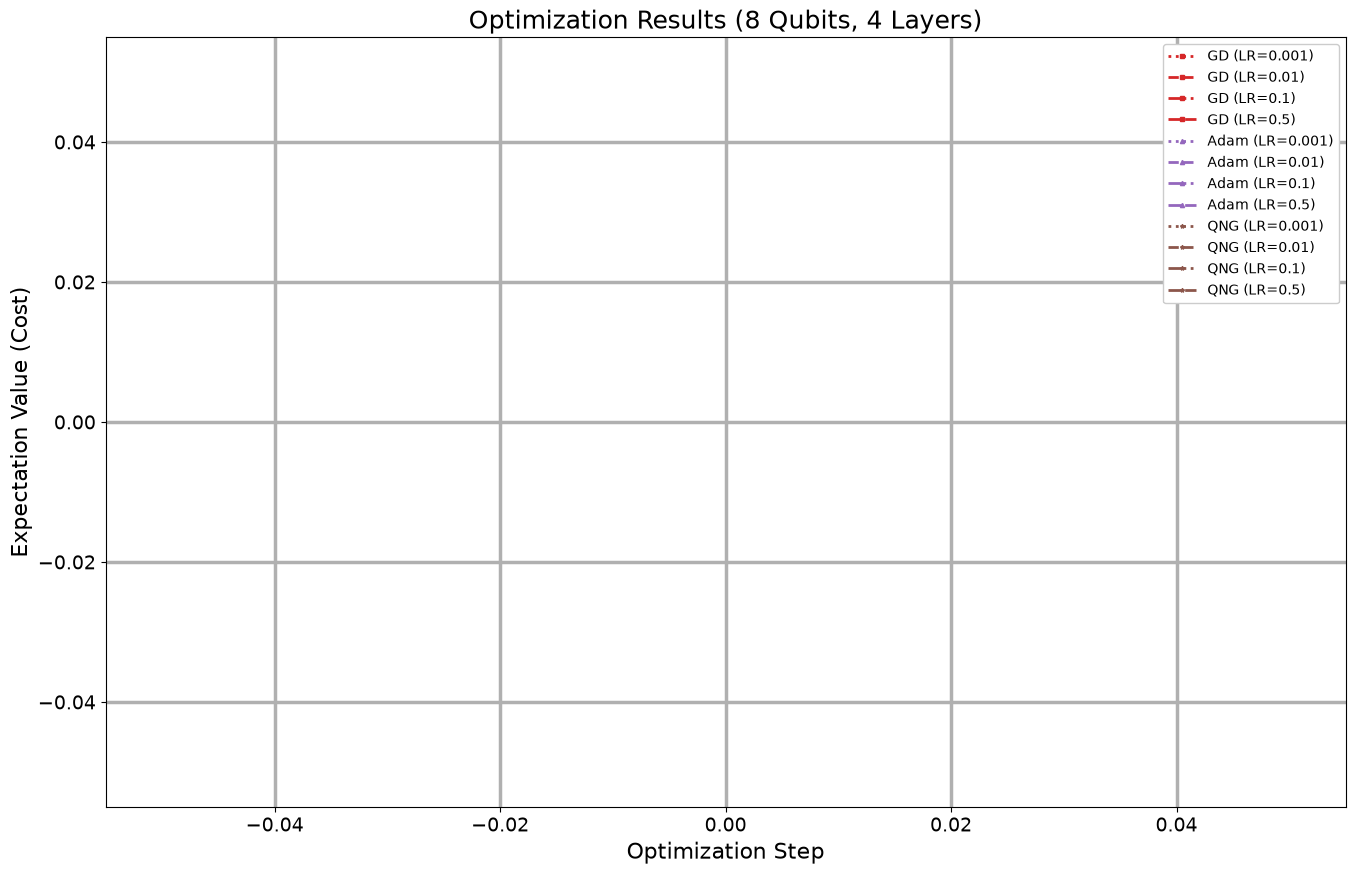

Saved plot: results/8q_4l.png


In [26]:
import os
import json
import matplotlib.pyplot as plt

# Directory containing the JSON result files
save_dir = "results"

# Look for all JSON files in the results directory
json_files = [f for f in os.listdir(save_dir) if f.endswith(".json")]

for json_file in json_files:
    json_path = os.path.join(save_dir, json_file)
    
    with open(json_path, "r") as f:
        data = json.load(f)
    
    num_qubits = data.get("num_qubits", "Unknown")
    num_layers = data.get("num_layers", "Unknown")
    
    # Setup plot with the exact figure size and style
    plt.figure(figsize=(16, 10))
    
    # 1. Plot Polyak -> GD and Polyak -> QNG (Best Curves)
    if "polyak_gd" in data and "best_loss 1" in data["polyak_gd"]:
        # Average across runs if multiple runs exist, or plot run 1
        best_gd = data["polyak_gd"]["best_loss 1"]
        plt.plot(best_gd, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
        
    if "polyak_qng" in data and "best_loss 1" in data["polyak_qng"]:
        best_qng = data["polyak_qng"]["best_loss 1"]
        plt.plot(best_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
    
    # Line styles for learning rate variations
    styles = [':', '--', '-.', (0, (5, 1))]
    
    # 2. Plot SGD / GD curves
    if "sgd" in data:
        for j, (lr_key, lr_data) in enumerate(data["sgd"].items()):
            lr_val = lr_key.replace("lr_", "")
            curve = lr_data.get("loss 1", [])
            style = styles[j % len(styles)]
            plt.plot(curve, marker='s', markersize=3, linestyle=style, color='tab:red', linewidth=2, label=f"GD (LR={lr_val})")
            
    # 3. Plot Adam curves
    if "adam" in data:
        for j, (lr_key, lr_data) in enumerate(data["adam"].items()):
            lr_val = lr_key.replace("lr_", "")
            curve = lr_data.get("loss 1", [])
            style = styles[j % len(styles)]
            plt.plot(curve, marker='^', markersize=3, linestyle=style, color='tab:purple', linewidth=2, label=f"Adam (LR={lr_val})")
            
    # 4. Plot QNG curves
    if "qng" in data:
        for j, (lr_key, lr_data) in enumerate(data["qng"].items()):
            lr_val = lr_key.replace("lr_", "")
            curve = lr_data.get("loss 1", [])
            style = styles[j % len(styles)]
            plt.plot(curve, marker='*', markersize=3, linestyle=style, color='tab:brown', linewidth=2, label=f"QNG (LR={lr_val})")

    # Axis Labels, Formatting & Grid
    plt.title(f"Optimization Results ({num_qubits} Qubits, {num_layers} Layers)", fontsize=18)
    plt.xlabel("Optimization Step", fontsize=16)
    plt.ylabel("Expectation Value (Cost)", fontsize=16)
    plt.tick_params(labelsize=14)
    plt.legend(fontsize=10, framealpha=1, loc='upper right')
    plt.grid(True, linewidth=2.5)
    
    # Save image with matching filename (e.g., results/4q_2l.png)
    image_filename = os.path.splitext(json_file)[0] + ".png"
    save_img_path = os.path.join(save_dir, image_filename)
    
    plt.savefig(save_img_path, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    
    print(f"Saved plot: {save_img_path}")

In [ ]:
# import pennylane as qml
# import torch

# # Standard PennyLane device (works on Windows)
# dev = qml.device("default.qubit", wires=num_qubits)

# @qml.qnode(dev, interface="torch")
# def circuit(params):
#     qml.RX(params[0], wires=0)
#     qml.RY(params[1], wires=1)
#     return qml.expval(qml.PauliZ(0))

# # Move input parameters directly to GPU memory
# params = torch.tensor([0.5, 0.1], requires_grad=True, device="cuda")

# # Run on GPU via PyTorch interface
# result = circuit(params)
# print("Result on GPU:", result)